# Insurance price predection project

### Problem Statement
- Predict individuals insurance charge

### Import required libraries

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load the data

In [56]:
df = pd.read_csv('./insurance.csv')

### Exporatory data analysis

In [57]:
# Get general information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [58]:
# Get stastical information
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [59]:
# Check for null values
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

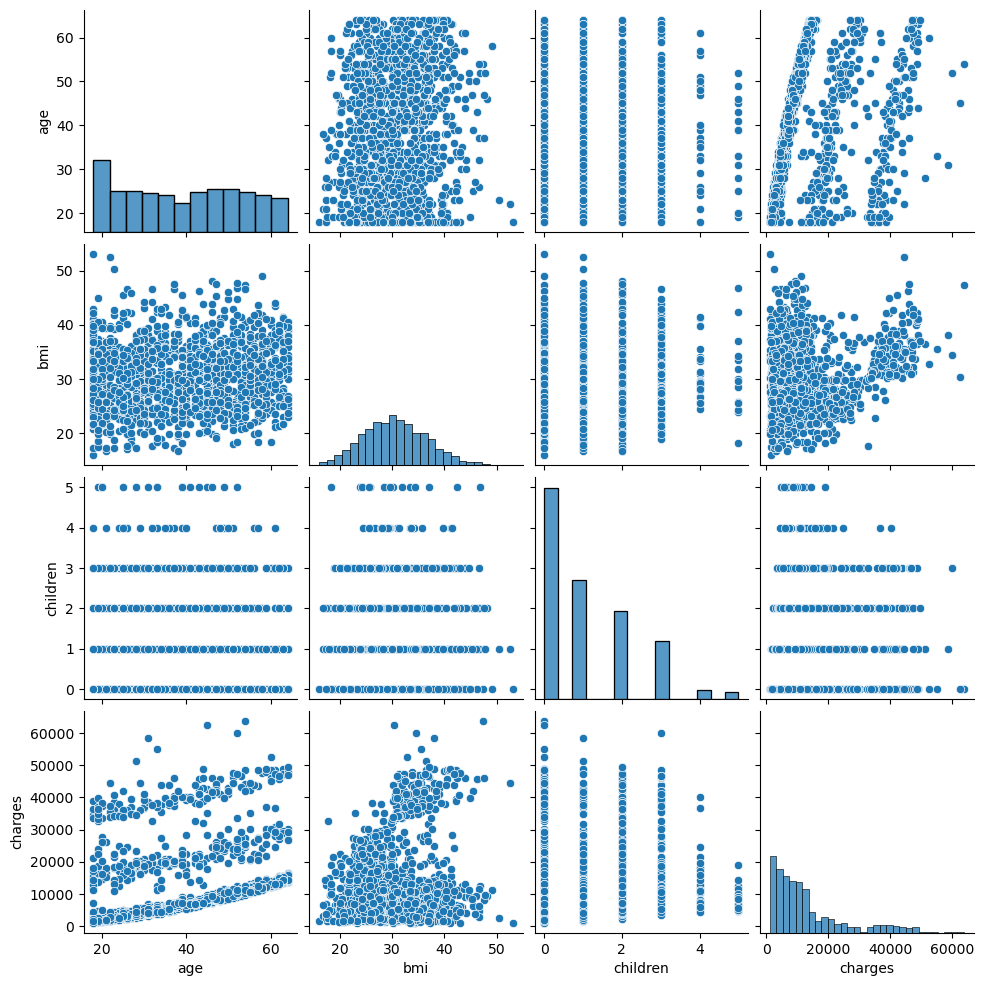

In [60]:
sns.pairplot(df)

In [61]:
### Categorical data to numerical

from sklearn.preprocessing import LabelEncoder

# For sex column

# Create Object of Label Encoder
encoder = LabelEncoder()
# Fit the data
encoder.fit(df['sex'])
# Transform the data
df['sex'] = encoder.transform(df['sex'])

# For Smoker column
# Create Object of Label Encoder
encoder = LabelEncoder()
# Fit the data
encoder.fit(df['smoker'])
# Transform the data
df['smoker'] = encoder.transform(df['smoker'])

In [62]:
df = pd.get_dummies(df, columns=['region'], drop_first=True, dtype=int)

In [63]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [64]:
# Correlational analysis
df.corr()['charges']

age                 0.299008
sex                 0.057292
bmi                 0.198341
children            0.067998
smoker              0.787251
charges             1.000000
region_northwest   -0.039905
region_southeast    0.073982
region_southwest   -0.043210
Name: charges, dtype: float64

### Split the data

In [65]:
# Split into x and y
x = df.drop(['charges'], axis = 1)
y = df['charges']

### Prepare the dataset

In [66]:
from sklearn.preprocessing import PolynomialFeatures

# Create object of polynomial features
polynomial_features = PolynomialFeatures(degree = 3)

# Fit and transform the data to get new x
x_new = polynomial_features.fit_transform(x)

In [67]:
# Train test split

from sklearn.model_selection import train_test_split

x_train , x_test, y_train, y_test = train_test_split(x_new, y, train_size=0.8, random_state=42)

### Train the model

In [68]:
from sklearn.linear_model import LinearRegression

# Create a model
model = LinearRegression()

# Train the model
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Evaluate the model

In [69]:
# Metrices for traning data
from sklearn.metrics import r2_score

y_pred_train = model.predict(x_train)
r2_train = r2_score(y_train, y_pred_train)
print(f"R2 Score on traning data is {r2_train}")

# Metrices for testing data
y_pred = model.predict(x_test)
r2 = r2_score(y_test, y_pred)
print(f"R2 Score on Testing data is {r2}")

R2 Score on traning data is 0.8549520260488752
R2 Score on Testing data is 0.8486414814916844


In [72]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("poly.pkl", "wb") as f:
    pickle.dump(polynomial_features, f)

In [73]:
print(x.columns.tolist())

['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']
